In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [ ]:
dataset = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(dataset)


In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
dataset = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(dataset)

# Convert TotalCharges to numeric (invalid parse -> NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encode target
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

# Drop customerID
df = df.drop('customerID', axis=1)

# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

# One-hot encode all categorical columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Scale numeric features
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ensure all features are numeric
X_train = X_train.apply(pd.to_numeric)
X_test = X_test.apply(pd.to_numeric)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)



X_train shape: (5634, 30)
X_test shape: (1409, 30)


In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)  # This will work now
y_pred_lr = lr.predict(X_test)

print("Training completed! Sample predictions:", y_pred_lr[:5])


Training completed! Sample predictions: [0 1 0 0 0]


In [30]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [31]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:17:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [32]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("XGBoost")
print(classification_report(y_test, y_pred_xgb))

Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

XGBoost
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.61      0.53      0.57       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.78      0.7

ROC-AUC Scores
LR: 0.8419954015861943
RF: 0.8249670619235836
XGB: 0.8214136247384329


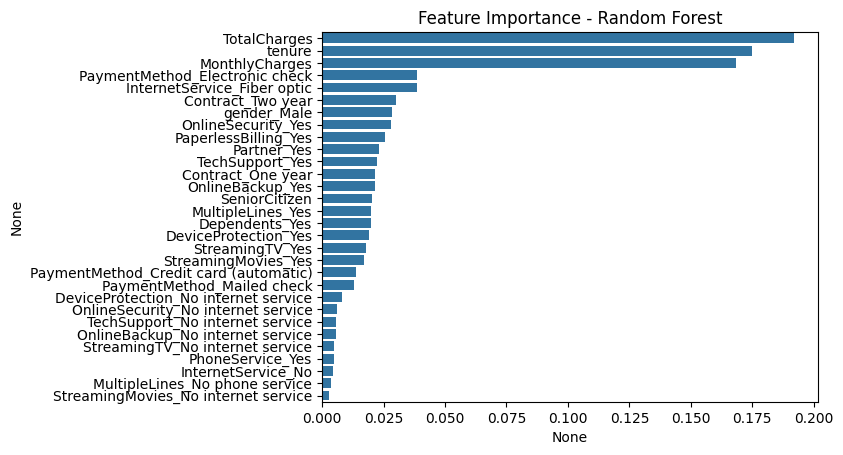

Top drivers of churn:
TotalCharges                      0.192096
tenure                            0.174733
MonthlyCharges                    0.168413
PaymentMethod_Electronic check    0.038771
InternetService_Fiber optic       0.038641
Contract_Two year                 0.030176
gender_Male                       0.028321
OnlineSecurity_Yes                0.028191
PaperlessBilling_Yes              0.025617
Partner_Yes                       0.023326
dtype: float64
Churn probability for sample customer: 0.00


In [34]:
print("ROC-AUC Scores")
print("LR:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))
print("RF:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
print("XGB:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

# 10️⃣ Feature Importance (Random Forest)
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title('Feature Importance - Random Forest')
plt.show()

# 11️⃣ Business Insights
print("Top drivers of churn:")
print(feat_imp.head(10))

# 12️⃣ Optional: Predict churn probability for new customer
sample_customer = X_test.iloc[0]
prob_churn = xgb_model.predict_proba([sample_customer])[0][1]
print(f"Churn probability for sample customer: {prob_churn:.2f}")